['ARCFILE', 'Object', 'RA', 'DEC', 'Filter', 'ABMAGLIM', 'Wavelength', 'SNR', 'R (&lambda;/&delta;&lambda;)', 'Product category', 'Instrument', 'Date Obs', 'Exptime', 'Collection', 'Product version', 'Run/Program ID', 'ORIGFILE', 'REFERENC']
          ARCFILE            Object ... REFERENC
--------------------------- ------- ... --------
ADP.2015-11-24T02:01:16.920 HD15906 ...       --
ADP.2014-10-01T10:23:36.003 HD15906 ...       --
ADP.2014-09-26T16:55:02.357 HD15906 ...       --
ADP.2018-02-10T01:01:20.825 HD15906 ...       --
ADP.2014-09-26T16:51:48.977 HD15906 ...       --
ADP.2014-09-26T16:51:36.523 HD15906 ...       --
ADP.2014-10-01T10:22:24.213 HD15906 ...       --
ADP.2015-11-29T02:00:53.643 HD15906 ...       --
ADP.2014-09-25T15:33:28.877 HD15906 ...       --
ADP.2014-09-29T13:27:15.353 HD15906 ...       --
Total rows: 50
Spectrum-like rows: 50
          ARCFILE            Object ... REFERENC
--------------------------- ------- ... --------
ADP.2015-11-24T02:01:16.920 HD1590

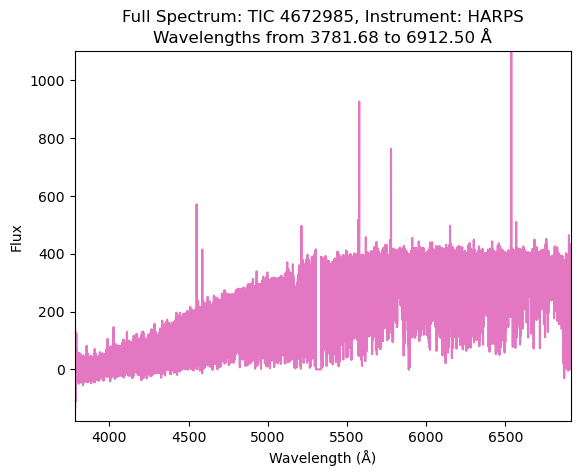


--- Centroid Check (should be close to reference wavelength) ---
H-alpha:  ref=6562.401 Å,  centroid=6562.617 Å,  offset=0.216 Å
Lithium:  ref=6707.360 Å,  centroid=6707.268 Å,  offset=-0.092 Å
Na D1:    ref=5889.550 Å,  centroid=5889.840 Å,  offset=0.290 Å
Mg b:     ref=5183.220 Å,  centroid=5183.329 Å,  offset=0.109 Å


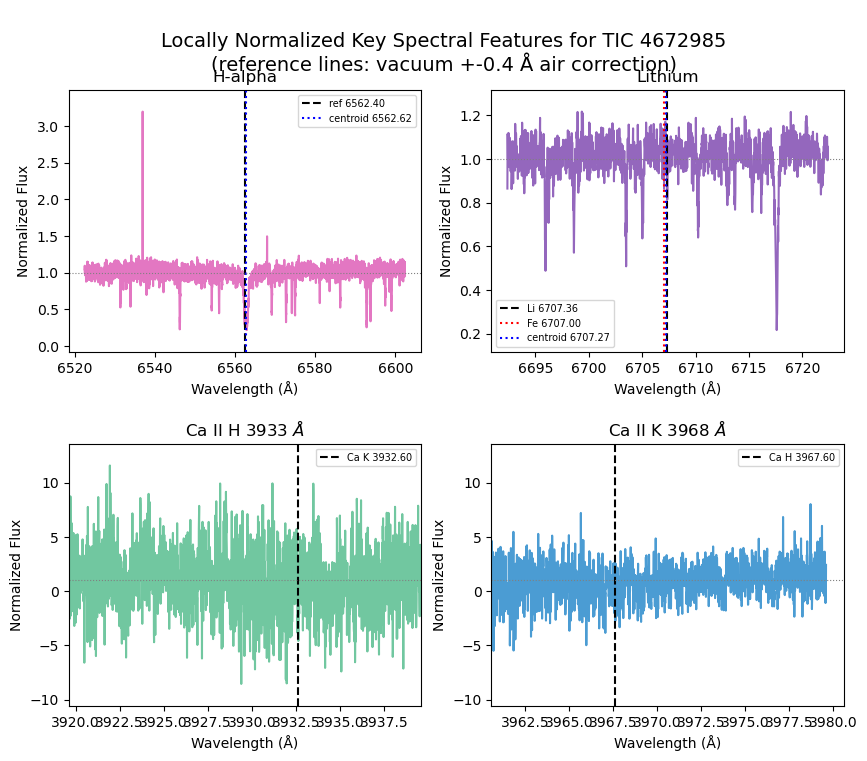

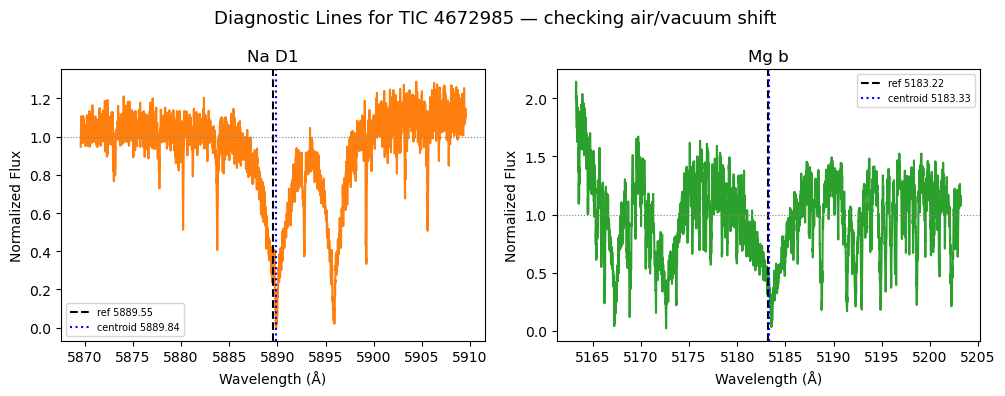

In [2]:
# ==== DOWNLOAD ***STAR*** DATA FROM ESO ARCHIVE AND PLOT ====

from astroquery.eso import Eso
from astropy.io import fits
from astropy.modeling import models, fitting
import numpy as np
import matplotlib.pyplot as plt
import os

from specutils import Spectrum, SpectralRegion
from specutils.manipulation import extract_region
import astropy.units as u


eso = Eso()
query = 'TIC 4672985'
instrument = 'HARPS'

results = eso.query_surveys(target=query, surveys=instrument)
print(results.colnames)
print(results[:10])

if "Product category" in results.colnames:
    spec_rows = [("SPECTRUM" in str(x)) for x in results["Product category"]]
    spec = results[spec_rows]
else:
    spec = results
print("Total rows:", len(results))
print("Spectrum-like rows:", len(spec))
print(spec[:10])

use = spec if len(spec) > 0 else results
arc = use["ARCFILE"][0]
print("Downloading ARCFILE:", arc)
downloaded = eso.retrieve_data(arc)
print("Downloaded:", downloaded)

path = downloaded[0] if isinstance(downloaded, (list, tuple)) else downloaded
hdul = fits.open(path)
hdul.info()

star = query
star_data = fits.open(path)
data = star_data[1].data
print(data.columns)

xvals = data['WAVE'][0]
yvals = data['FLUX'][0]

xmin = xvals[0]
xmax = xvals[-1]
print("Wavelength range:", xmin, "to", xmax)

plt.plot(xvals, yvals, color='tab:pink')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title(f'Full Spectrum: {star}, Instrument: {instrument}\nWavelengths from {xmin:.2f} to {xmax:.2f} Å')
plt.autoscale(enable=True, axis='both', tight=True)
filename = f"Spectrum_{star}_{instrument}_{xmin:.2f}-{xmax:.2f}.png"
plt.savefig(filename)
plt.show()


# ==== VACUUM WAVELENGTH CORRECTION ====
# HARPS data is in air wavelengths, NIST reference lines are in vacuum
# air-to-vacuum offset is ~0.4 Å at these wavelengths (as per Dr. Mann)
# fix: add 0.4 Å to all reference line markers so they align with the data

VAC_CORR = -0.4  # Angstroms, air-to-vacuum correction

# reference wavelengths (vacuum, from NIST) — corrected for air frame
ha_ref   = 6562.801 + VAC_CORR  # H-alpha
li_ref   = 6707.76  + VAC_CORR  # Lithium I
fe_ref   = 6707.4   + VAC_CORR  # Fe I (near Li)
cahk_h   = 3968.0   + VAC_CORR  # Ca II H
cahk_k   = 3933.0   + VAC_CORR  # Ca II K

# additional diagnostic lines to check shift is consistent
na_ref   = 5889.95  + VAC_CORR  # Na D1
mg_ref   = 5183.62  + VAC_CORR  # Mg b


# ==== LOCAL CONTINUUM NORMALIZATION ====

spectrum = Spectrum(
    spectral_axis=xvals * u.AA,
    flux=yvals * u.Unit('erg / (cm^2 s AA)')
)

def local_normalize(spectrum, line_center, window=20, shoulder=5):
    # extract window around line
    lo = line_center - window
    hi = line_center + window

    region = SpectralRegion(lo * u.AA, hi * u.AA)
    try:
        sub = extract_region(spectrum, region)
    except Exception:
        print(f"Warning: {lo}-{hi} Å not covered, skipping.")
        return None, None

    wave = sub.spectral_axis.value
    flux = sub.flux.value

    # fit continuum on shoulder regions only, mask out line core
    shoulder_mask = (wave < line_center - shoulder) | (wave > line_center + shoulder)

    try:
        p_init = models.Chebyshev1D(1)
        fitter = fitting.LinearLSQFitter()
        p = fitter(p_init, wave[shoulder_mask], flux[shoulder_mask])
        continuum = p(wave)
        flux_norm = flux / continuum
    except Exception as e:
        print(f"Warning: continuum fit failed around {line_center} Å: {e}")
        return None, None

    return wave, flux_norm


def centroid(wave, flux_norm, line_center, half_width=3):
    # calculate centroid of line to find actual line center
    # uses flux *deficit* (1 - flux) so absorption lines have positive weight
    mask = (wave > line_center - half_width) & (wave < line_center + half_width)
    w = wave[mask]
    f = flux_norm[mask]
    deficit = 1.0 - f
    deficit = np.clip(deficit, 0, None)  # ignore emission spikes
    if deficit.sum() == 0:
        return None
    return np.sum(w * deficit) / np.sum(deficit)


# normalize around each feature (using corrected reference centers)
wave_ha,   flux_ha   = local_normalize(spectrum, line_center=ha_ref,  window=40, shoulder=8)
wave_li,   flux_li   = local_normalize(spectrum, line_center=li_ref,  window=15, shoulder=4)
wave_cahk, flux_cahk = local_normalize(spectrum, line_center=3950.0 + VAC_CORR, window=30, shoulder=8)
wave_na,   flux_na   = local_normalize(spectrum, line_center=na_ref,  window=20, shoulder=6)
wave_mg,   flux_mg   = local_normalize(spectrum, line_center=mg_ref,  window=20, shoulder=6)

# calculate centroids and print to check shift
print("\n--- Centroid Check (should be close to reference wavelength) ---")
if wave_ha is not None:
    c_ha = centroid(wave_ha, flux_ha, ha_ref)
    print(f"H-alpha:  ref={ha_ref:.3f} Å,  centroid={c_ha:.3f} Å,  offset={c_ha - ha_ref:.3f} Å")
if wave_li is not None:
    c_li = centroid(wave_li, flux_li, li_ref)
    print(f"Lithium:  ref={li_ref:.3f} Å,  centroid={c_li:.3f} Å,  offset={c_li - li_ref:.3f} Å")
if wave_na is not None:
    c_na = centroid(wave_na, flux_na, na_ref)
    print(f"Na D1:    ref={na_ref:.3f} Å,  centroid={c_na:.3f} Å,  offset={c_na - na_ref:.3f} Å")
if wave_mg is not None:
    c_mg = centroid(wave_mg, flux_mg, mg_ref)
    print(f"Mg b:     ref={mg_ref:.3f} Å,  centroid={c_mg:.3f} Å,  offset={c_mg - mg_ref:.3f} Å")


# ==== 4-PANEL PLOT ====
figures, graphs = plt.subplots(2, 2, figsize=(10, 8))
plt.suptitle(f'\nLocally Normalized Key Spectral Features for {star}\n(reference lines: vacuum +{VAC_CORR} Å air correction)', fontsize=14)
plt.subplots_adjust(hspace=0.35)

# H-alpha
if wave_ha is not None:
    graphs[0,0].plot(wave_ha, flux_ha, 'tab:pink')
    graphs[0,0].axvline(x=ha_ref, color='black', ls='--', label=f'ref {ha_ref:.2f}')
    if wave_ha is not None:
        c = centroid(wave_ha, flux_ha, ha_ref)
        if c: graphs[0,0].axvline(x=c, color='blue', ls=':', label=f'centroid {c:.2f}')
    graphs[0,0].axhline(y=1.0, color='gray', ls=':', linewidth=0.8)
    pad = 0.1 * (flux_ha.max() - flux_ha.min())
    graphs[0,0].set_ylim(flux_ha.min() - pad, flux_ha.max() + pad)
    graphs[0,0].legend(fontsize=7)
else:
    graphs[0,0].text(0.5, 0.5, 'Not covered', ha='center', va='center', transform=graphs[0,0].transAxes)
graphs[0,0].set_title(r'H-alpha')
graphs[0,0].set_xlabel('Wavelength (Å)')
graphs[0,0].set_ylabel('Normalized Flux')

# Lithium + Fe
if wave_li is not None:
    graphs[0,1].plot(wave_li, flux_li, 'tab:purple')
    graphs[0,1].axvline(x=li_ref, color='black', ls='--', label=f'Li {li_ref:.2f}')
    graphs[0,1].axvline(x=fe_ref, color='red',   ls=':',  label=f'Fe {fe_ref:.2f}')
    if wave_li is not None:
        c = centroid(wave_li, flux_li, li_ref)
        if c: graphs[0,1].axvline(x=c, color='blue', ls=':', label=f'centroid {c:.2f}')
    graphs[0,1].axhline(y=1.0, color='gray', ls=':', linewidth=0.8)
    pad = 0.1 * (flux_li.max() - flux_li.min())
    graphs[0,1].set_ylim(flux_li.min() - pad, flux_li.max() + pad)
    graphs[0,1].legend(fontsize=7)
else:
    graphs[0,1].text(0.5, 0.5, 'Not covered', ha='center', va='center', transform=graphs[0,1].transAxes)
graphs[0,1].set_title(r'Lithium')
graphs[0,1].set_xlabel('Wavelength (Å)')
graphs[0,1].set_ylabel('Normalized Flux')

# Ca II H
if wave_cahk is not None:
    graphs[1,0].plot(wave_cahk, flux_cahk, '#71C7A0')
    graphs[1,0].axvline(x=cahk_k, color='black', ls='--', label=f'Ca K {cahk_k:.2f}')
    graphs[1,0].axhline(y=1.0, color='gray', ls=':', linewidth=0.8)
    graphs[1,0].set_xlim(cahk_k - 13, cahk_k + 7)
    pad = 0.1 * (flux_cahk.max() - flux_cahk.min())
    graphs[1,0].set_ylim(flux_cahk.min() - pad, flux_cahk.max() + pad)
    graphs[1,0].legend(fontsize=7)
else:
    graphs[1,0].text(0.5, 0.5, 'Not covered', ha='center', va='center', transform=graphs[1,0].transAxes)
graphs[1,0].set_title(r'Ca II H 3933 $\AA$')
graphs[1,0].set_xlabel('Wavelength (Å)')
graphs[1,0].set_ylabel('Normalized Flux')

# Ca II K
if wave_cahk is not None:
    graphs[1,1].plot(wave_cahk, flux_cahk, '#4B9CD3')
    graphs[1,1].axvline(x=cahk_h, color='black', ls='--', label=f'Ca H {cahk_h:.2f}')
    graphs[1,1].axhline(y=1.0, color='gray', ls=':', linewidth=0.8)
    graphs[1,1].set_xlim(cahk_h - 7, cahk_h + 13)
    pad = 0.1 * (flux_cahk.max() - flux_cahk.min())
    graphs[1,1].set_ylim(flux_cahk.min() - pad, flux_cahk.max() + pad)
    graphs[1,1].legend(fontsize=7)
else:
    graphs[1,1].text(0.5, 0.5, 'Not covered', ha='center', va='center', transform=graphs[1,1].transAxes)
graphs[1,1].set_title(r'Ca II K 3968 $\AA$')
graphs[1,1].set_xlabel('Wavelength (Å)')
graphs[1,1].set_ylabel('Normalized Flux')

filename2 = f"Features_{star}_{instrument}_localnorm_vaccorr.png"
plt.savefig(filename2)
plt.show()


# ==== DIAGNOSTIC: Na and Mg to confirm shift is consistent ====
fig2, ax = plt.subplots(1, 2, figsize=(10, 4))
plt.suptitle(f'Diagnostic Lines for {star} — checking air/vacuum shift', fontsize=13)

if wave_na is not None:
    ax[0].plot(wave_na, flux_na, 'tab:orange')
    ax[0].axvline(x=na_ref, color='black', ls='--', label=f'ref {na_ref:.2f}')
    c = centroid(wave_na, flux_na, na_ref)
    if c: ax[0].axvline(x=c, color='blue', ls=':', label=f'centroid {c:.2f}')
    ax[0].axhline(y=1.0, color='gray', ls=':', linewidth=0.8)
    ax[0].legend(fontsize=7)
else:
    ax[0].text(0.5, 0.5, 'Not covered', ha='center', va='center', transform=ax[0].transAxes)
ax[0].set_title('Na D1')
ax[0].set_xlabel('Wavelength (Å)')
ax[0].set_ylabel('Normalized Flux')

if wave_mg is not None:
    ax[1].plot(wave_mg, flux_mg, 'tab:green')
    ax[1].axvline(x=mg_ref, color='black', ls='--', label=f'ref {mg_ref:.2f}')
    c = centroid(wave_mg, flux_mg, mg_ref)
    if c: ax[1].axvline(x=c, color='blue', ls=':', label=f'centroid {c:.2f}')
    ax[1].axhline(y=1.0, color='gray', ls=':', linewidth=0.8)
    ax[1].legend(fontsize=7)
else:
    ax[1].text(0.5, 0.5, 'Not covered', ha='center', va='center', transform=ax[1].transAxes)
ax[1].set_title('Mg b')
ax[1].set_xlabel('Wavelength (Å)')
ax[1].set_ylabel('Normalized Flux')

plt.tight_layout()
plt.savefig(f"Diagnostic_{star}_{instrument}_NaMg.png")
plt.show()